In [ ]:
"""
Author: eveie Prewitt
Exploritory data analysis for the Strait of Hormuz project.
This is a Jupyter notebook containing code for the visuals
used the the EDA section of the final project report.
This notebook is for analysis only and is not intended to be run as a script.
"""

In [1]:
import mapping

In [4]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
presence_90 = pd.read_csv('presence_hormuz_2026-04-30_2026-07-29.csv')
presence_peaceful = pd.read_csv('peacetime_hormuz_2022-01-01_2022-12-31.csv')
snap = pd.read_csv('snapshot_hormuz_20260803T050455Z.csv')
presence_90.head()

,date,flag,gear_type,hours,vessel_id,vessel_type,entry_timestamp,exit_timestamp,first_transmission_date,last_transmission_date,imo,mmsi,call_sign,dataset,report_dataset,ship_name,lat,lon
0,2026-07-17,MDG,CARGO,6.0,77813c143-3689-4e6d-1fd8-79db6f9694fe,CARGO,2026-05-05T05:00:00Z,2026-07-17T05:00:00Z,2026-02-06T09:59:57Z,2026-07-17T05:00:57Z,9273002.0,647553004.0,5RA04,public-global-vessel-identity:v4.0,public-global-presence:v4.0,STARBOUND EXPLORER,26.0,55.799999
1,2026-05-01,IRN,CARGO,1.0,67ab33f72-2f5f-9631-3ec0-ff0834deee88,CARGO,2026-04-30T03:00:00Z,2026-05-22T14:00:00Z,2017-11-06T08:00:21Z,2026-07-31T23:28:22Z,9795036.0,422085700.0,EPDZ2,public-global-vessel-identity:v4.0,public-global-presence:v4.0,NEZAMI GANJAVI 5,25.4,57.200001
2,2026-06-23,IRN,CARGO,1.0,471c6c376-6553-582f-6b03-502410126e90,CARGO,2026-04-30T11:00:00Z,2026-07-10T09:00:00Z,2012-10-16T17:42:33Z,2026-07-31T23:55:33Z,8508462.0,422141000.0,EQKF,public-global-vessel-identity:v4.0,public-global-presence:v4.0,BANEH,26.6,55.700001
3,2026-07-05,BES,CARGO,24.0,632a5c38c-c648-a7d2-c97a-a9d0ce6194a8,CARGO,2026-04-30T03:00:00Z,2026-07-11T18:00:00Z,2024-10-01T06:04:37Z,2026-07-31T23:56:21Z,9309239.0,306885000.0,8PJG6,public-global-vessel-identity:v4.0,public-global-presence:v4.0,OLGA,25.7,57.000000
4,2026-07-04,COM,CARGO,1.0,c175d823a-a4e4-382c-7e12-67284569fdef,CARGO,2026-06-11T09:00:00Z,2026-07-18T17:00:00Z,2024-01-30T11:50:52Z,2026-07-21T04:19:34Z,8936372.0,620999370.0,D6A3369,public-global-vessel-identity:v4.0,public-global-presence:v4.0,SHAHIN 2,25.6,55.400002


AttributeError: Line2D.set() got an unexpected keyword argument 'hue'

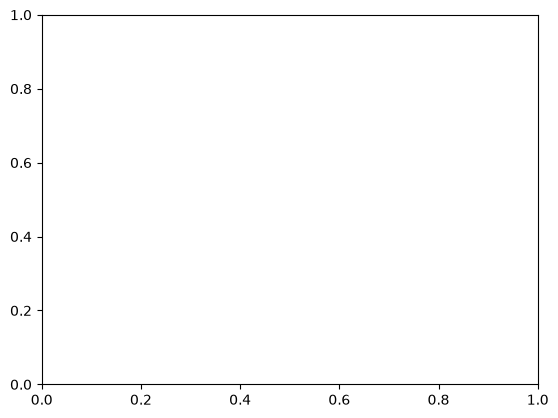

In [13]:
# returns a graph of the flag counts by time stamp for the presence_90 dataset
flag_grouped = presence_90.groupby(['flag', 'entry_timestamp', 'exit_timestamp']).size().reset_index(name='count')
flag_grouped.plot(x='entry_timestamp', y='count', kind='line', hue='flag', title='Presence 90 Days by Flag')



In [ ]:
# Creates density maps for the presence_90 and peacetime datasets, and saves them as images. 
mapping.draw('presence_hormuz_2026-04-30_2026-07-29.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)
mapping.draw('peacetime_hormuz_2022-01-01_2022-12-31.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

wrote presence_hormuz_2026-04-30_2026-07-29_diff.png


'presence_hormuz_2026-04-30_2026-07-29_diff.png'

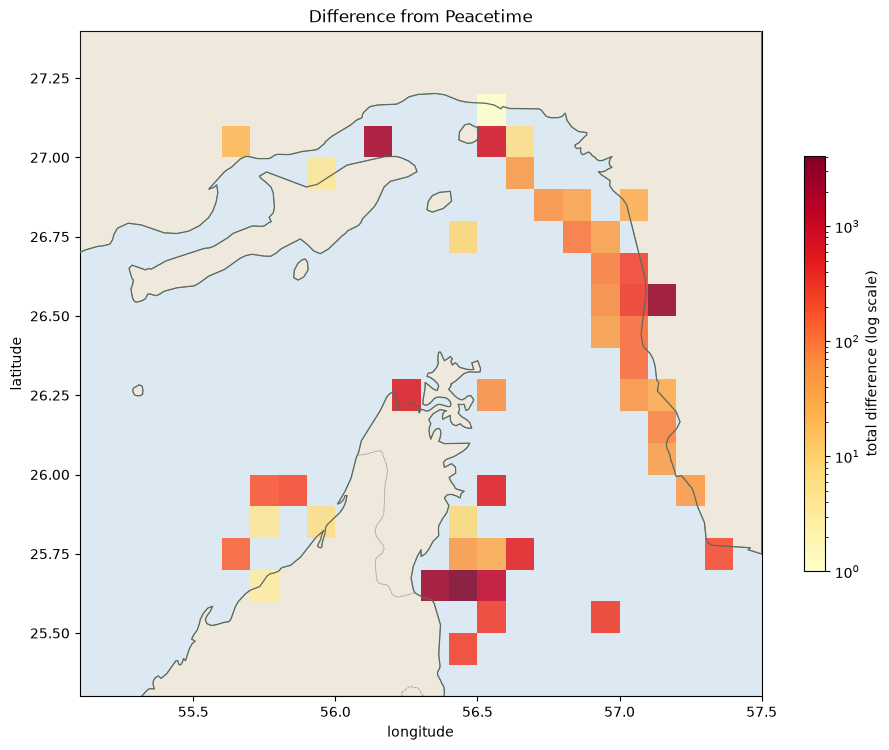

In [ ]:
# Compares the presence_90 dataset to the peacetime dataset, and gives a map of the difference in vessel presence, and saves it as an image.
mapping.compare_to_peacetime('presence_hormuz_2026-04-30_2026-07-29.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

In [ ]:
# Creates a map of the Strait of Hormuz from a snapshot of AIS data, with points noting the
# locations of tanker vessels.
mapping.draw('snapshot_hormuz_20260803T050455Z.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)